# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Candidates Full Dataset](https://www.kaggle.com/datasets/ameliaberignton/it-job-seekers-skills/data)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('candidates_full.csv')

# Preprocessing

## Frist five row

In [3]:
pd.set_option('display.max_columns', None)
df.head()

,candidate_id,job_role,job_role_display,gender,age_group,edu_level,edu_level_name,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,S_int,CSS,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
0,SE00001,Software_Engineer,Software Engineer,M,40+,3,MSc,1.2,0.7246,0.7925,0.5197,0.5872,0.7699,0.4,0.6515,0.5997,0.6080,0.6047,0,2,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
1,SE00002,Software_Engineer,Software Engineer,M,26-30,2,BSc,0.0,0.5713,0.6344,0.3932,0.3661,0.5885,0.0,0.4365,0.3359,0.4279,0.3911,0,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
2,SE00003,Software_Engineer,Software Engineer,M,31-35,2,BSc,10.4,0.7052,0.6523,0.7043,0.9604,0.6421,1.0,0.7727,0.8148,0.8220,0.8191,1,3,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
3,SE00004,Software_Engineer,Software Engineer,M,31-35,2,BSc,4.0,0.5019,0.5709,0.7013,0.4810,0.5608,1.0,0.7367,0.7805,0.5651,0.6513,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6
4,SE00005,Software_Engineer,Software Engineer,M,22-25,4,PhD,4.5,0.8334,0.5413,0.7418,0.6529,0.9334,1.0,0.5989,0.7861,0.6573,0.7088,1,1,0.2,0.3,0.5,0.2,0.3,0.5,0.4,0.6


## last Five row

In [4]:
df.tail()

,candidate_id,job_role,job_role_display,gender,age_group,edu_level,edu_level_name,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,S_int,CSS,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code,W_CV,W_INT
11995,EMB00596,Embedded_Systems_Engineer,Embedded Systems Engineer,M,22-25,3,MSc,7.6,0.695,0.8664,0.7191,1.0000,0.7580,1.0,0.8005,0.8618,0.8823,0.8741,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11996,EMB00597,Embedded_Systems_Engineer,Embedded Systems Engineer,M,36-40,3,MSc,6.2,0.824,0.7825,0.9111,1.0000,0.8096,1.0,0.8423,0.8910,0.9190,0.9078,1,2,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11997,EMB00598,Embedded_Systems_Engineer,Embedded Systems Engineer,M,36-40,2,BSc,4.1,0.675,0.8299,0.8738,0.9384,0.6300,1.0,0.4662,0.6858,0.8919,0.8095,1,1,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11998,EMB00599,Embedded_Systems_Engineer,Embedded Systems Engineer,M,26-30,3,MSc,4.5,0.661,0.9435,0.7079,1.0000,0.7444,1.0,0.8383,0.8761,0.8982,0.8894,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6
11999,EMB00600,Embedded_Systems_Engineer,Embedded Systems Engineer,M,31-35,4,PhD,4.3,0.827,0.5819,0.6525,1.0000,0.9308,1.0,0.7367,0.8677,0.7912,0.8218,1,3,0.2,0.35,0.45,0.25,0.3,0.45,0.4,0.6


## Shape of our dataset

In [5]:
df.shape

(12000, 28)

## List out all columns

In [6]:
df.columns

Index(['candidate_id', 'job_role', 'job_role_display', 'gender', 'age_group',
       'edu_level', 'edu_level_name', 'years_experience', 'edu_relevance',
       'P_mcq', 'P_desc', 'P_code', 'S_edu', 'S_exp', 'S_skill', 'S_cv',
       'S_int', 'CSS', 'passed_hard_filter', 'relevance_label', 'w_edu',
       'w_exp', 'w_skill', 'w_mcq', 'w_desc', 'w_code', 'W_CV', 'W_INT'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

candidate_id           object
job_role               object
job_role_display       object
gender                 object
age_group              object
edu_level               int64
edu_level_name         object
years_experience      float64
edu_relevance         float64
P_mcq                 float64
P_desc                float64
P_code                float64
S_edu                 float64
S_exp                 float64
S_skill               float64
S_cv                  float64
S_int                 float64
CSS                   float64
passed_hard_filter      int64
relevance_label         int64
w_edu                 float64
w_exp                 float64
w_skill               float64
w_mcq                 float64
w_desc                float64
w_code                float64
W_CV                  float64
W_INT                 float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   candidate_id        12000 non-null  object 
 1   job_role            12000 non-null  object 
 2   job_role_display    12000 non-null  object 
 3   gender              12000 non-null  object 
 4   age_group           12000 non-null  object 
 5   edu_level           12000 non-null  int64  
 6   edu_level_name      12000 non-null  object 
 7   years_experience    12000 non-null  float64
 8   edu_relevance       12000 non-null  float64
 9   P_mcq               12000 non-null  float64
 10  P_desc              12000 non-null  float64
 11  P_code              12000 non-null  float64
 12  S_edu               12000 non-null  float64
 13  S_exp               12000 non-null  float64
 14  S_skill             12000 non-null  float64
 15  S_cv                12000 non-null  float64
 16  S_in

## Check Null Value

In [9]:
df.isnull().sum()

candidate_id          0
job_role              0
job_role_display      0
gender                0
age_group             0
edu_level             0
edu_level_name        0
years_experience      0
edu_relevance         0
P_mcq                 0
P_desc                0
P_code                0
S_edu                 0
S_exp                 0
S_skill               0
S_cv                  0
S_int                 0
CSS                   0
passed_hard_filter    0
relevance_label       0
w_edu                 0
w_exp                 0
w_skill               0
w_mcq                 0
w_desc                0
w_code                0
W_CV                  0
W_INT                 0
dtype: int64

## Drop Useless Features

In [10]:
df = df.drop(columns=['W_CV', 'W_INT'])

## Check Dupicate Value

In [11]:
df.duplicated().sum()

np.int64(0)

## Summary

In [12]:
df.describe()

,edu_level,years_experience,edu_relevance,P_mcq,P_desc,P_code,S_edu,S_exp,S_skill,S_cv,S_int,CSS,passed_hard_filter,relevance_label,w_edu,w_exp,w_skill,w_mcq,w_desc,w_code
count,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000
mean,2.441167,4.042050,0.673524,0.759571,0.748888,0.779324,0.682349,0.847342,0.713764,0.753719,0.770740,0.763931,0.784000,2.081417,0.195000,0.332500,0.472500,0.257500,0.365000,0.377500
std,0.716762,2.343824,0.141287,0.135562,0.160250,0.165866,0.117395,0.286323,0.139180,0.131132,0.123836,0.111435,0.411531,0.936409,0.041535,0.042649,0.053563,0.048155,0.077624,0.120913
min,1.000000,0.000000,0.100000,0.290400,0.193800,0.146900,0.310300,0.000000,0.187400,0.204700,0.353200,0.328100,0.000000,0.000000,0.150000,0.250000,0.400000,0.200000,0.300000,0.150000
25%,2.000000,2.300000,0.581000,0.661175,0.635100,0.662275,0.604700,0.833300,0.617700,0.693575,0.678800,0.689500,1.000000,2.000000,0.150000,0.300000,0.450000,0.200000,0.300000,0.275000
50%,2.000000,3.900000,0.679050,0.759100,0.757150,0.791100,0.663850,1.000000,0.716100,0.781050,0.782200,0.774400,1.000000,2.000000,0.200000,0.325000,0.450000,0.250000,0.350000,0.400000
75%,3.000000,5.600000,0.769000,0.858600,0.874200,0.919900,0.765600,1.000000,0.811425,0.844600,0.871300,0.850700,1.000000,3.000000,0.200000,0.350000,0.512500,0.300000,0.412500,0.500000
max,4.000000,13.800000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.998400,1.000000,0.993200,1.000000,3.000000,0.300000,0.400000,0.550000,0.350000,0.500000,0.500000


# EDA

In [13]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

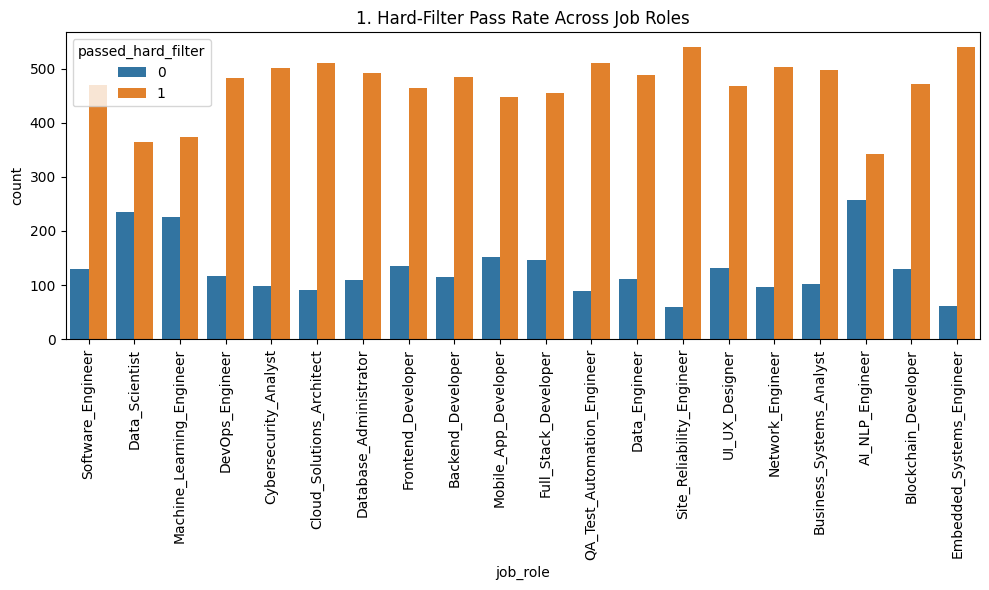

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='job_role', hue='passed_hard_filter')
plt.title(f'{plot_no}. Hard-Filter Pass Rate Across Job Roles')
plt.xticks(rotation=90)
show_fig()
plot_no += 1

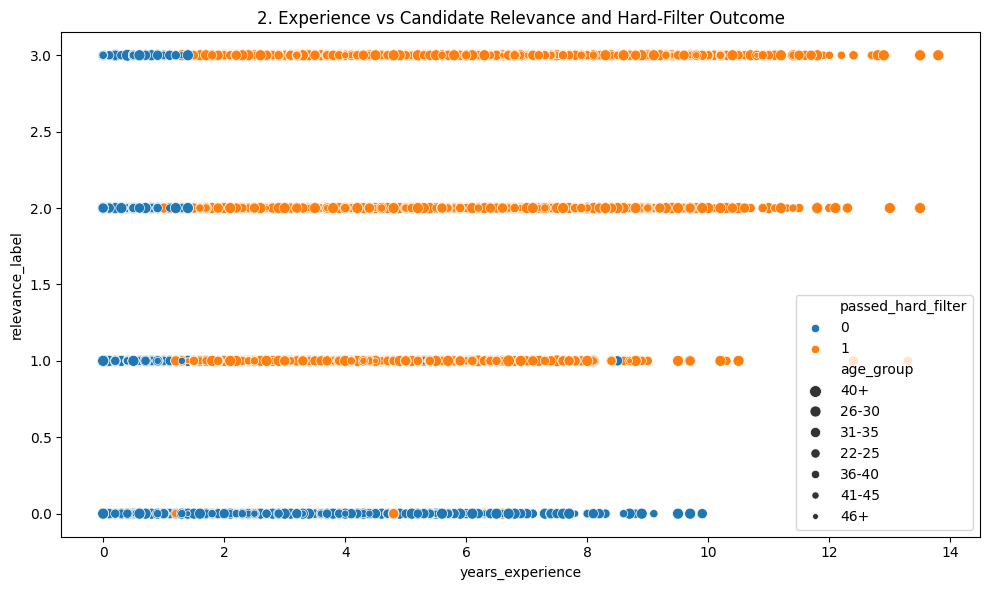

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='years_experience', y='relevance_label', hue='passed_hard_filter', size='age_group')
plt.title(f'{plot_no}. Experience vs Candidate Relevance and Hard-Filter Outcome')
show_fig()
plot_no += 1

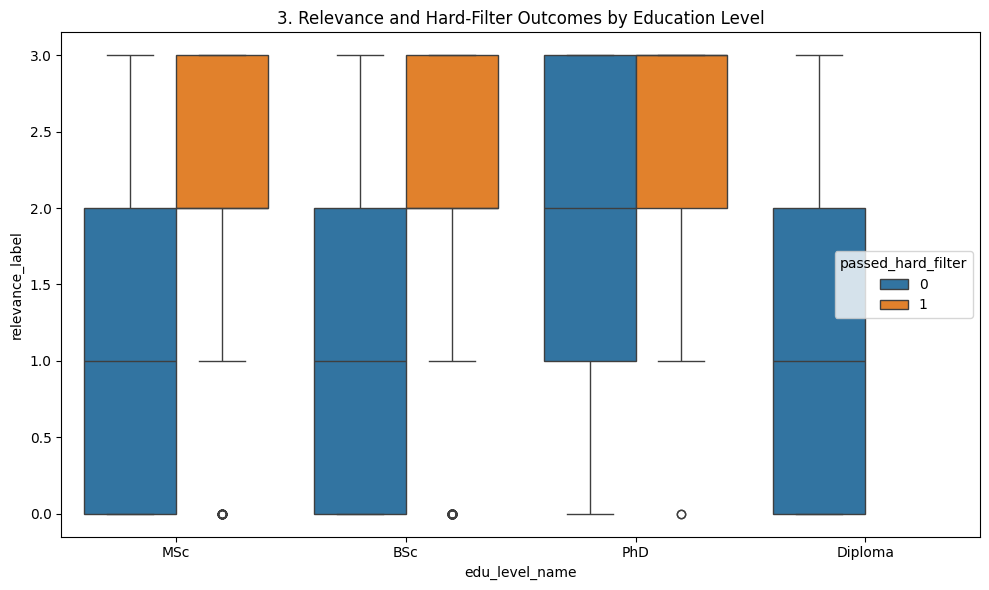

In [16]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='edu_level_name', y='relevance_label', hue='passed_hard_filter')
plt.title(f'{plot_no}. Relevance and Hard-Filter Outcomes by Education Level')
show_fig()
plot_no += 1

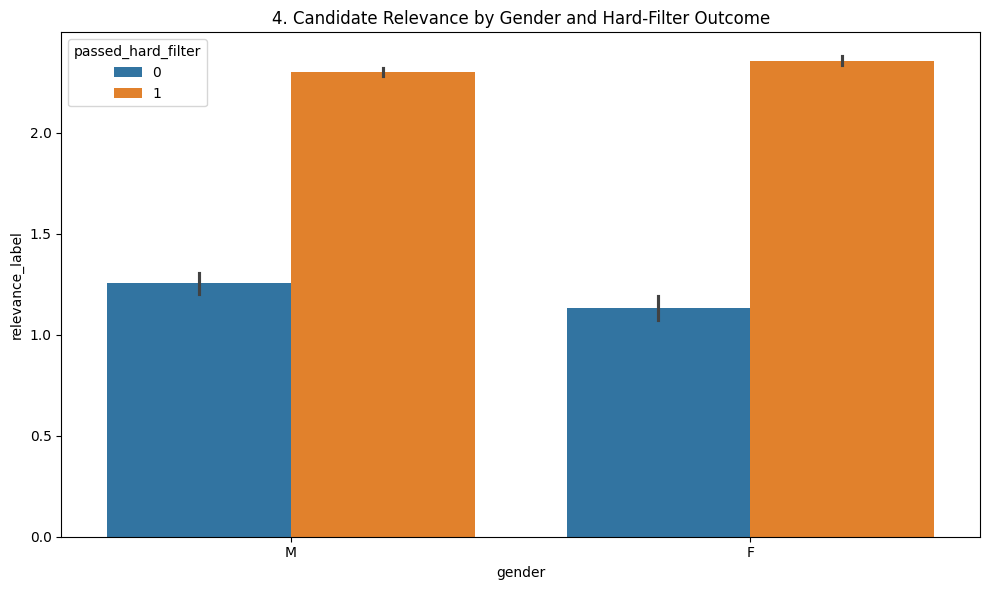

In [17]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='gender', y='relevance_label', hue='passed_hard_filter')
plt.title(f'{plot_no}. Candidate Relevance by Gender and Hard-Filter Outcome')
show_fig()
plot_no += 1

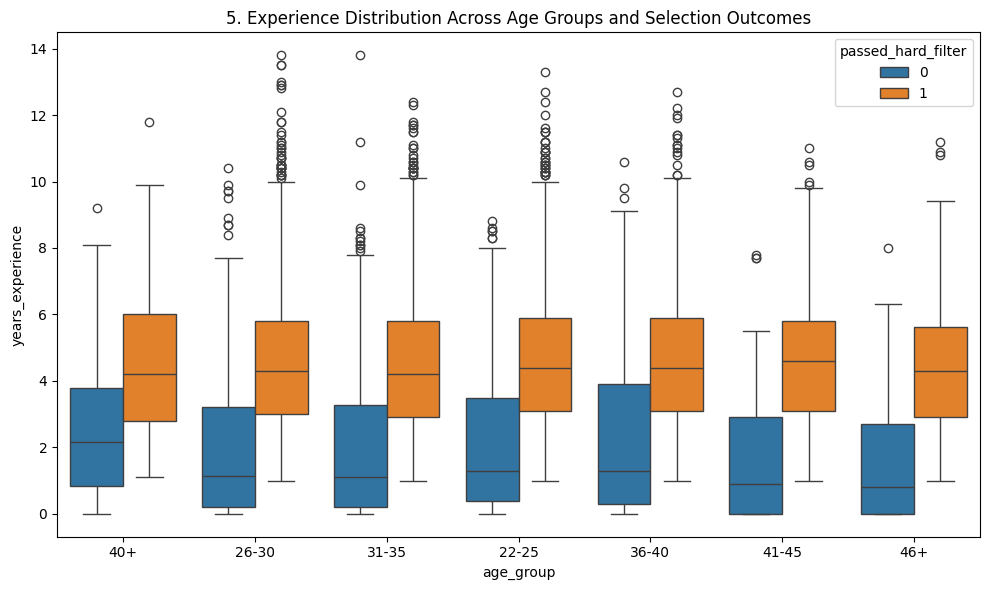

In [18]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='age_group', y='years_experience', hue='passed_hard_filter')
plt.title(f'{plot_no}. Experience Distribution Across Age Groups and Selection Outcomes')
show_fig()
plot_no += 1

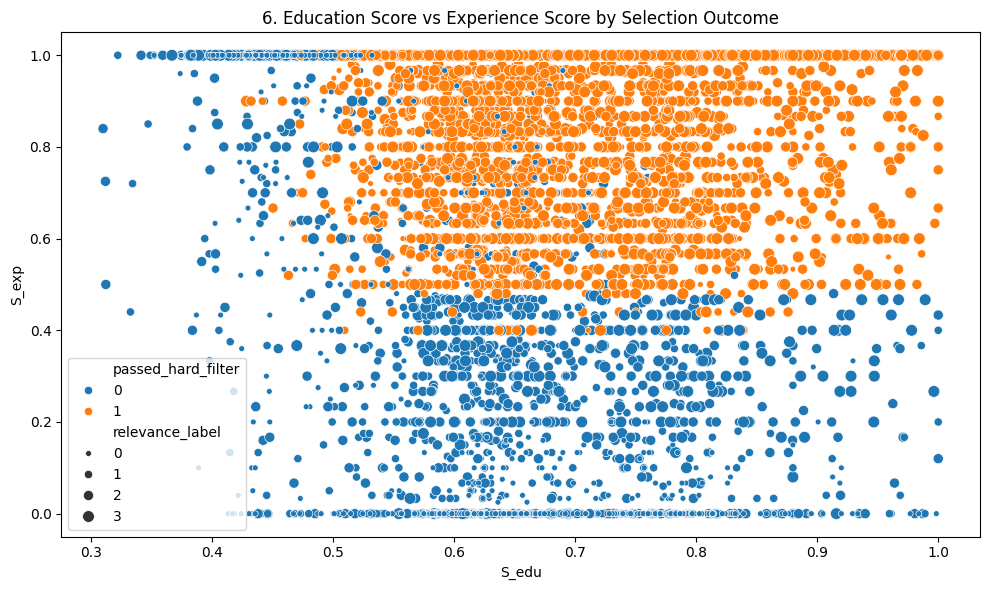

In [19]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='S_edu', y='S_exp', hue='passed_hard_filter', size='relevance_label')
plt.title(f'{plot_no}. Education Score vs Experience Score by Selection Outcome')
show_fig()
plot_no += 1

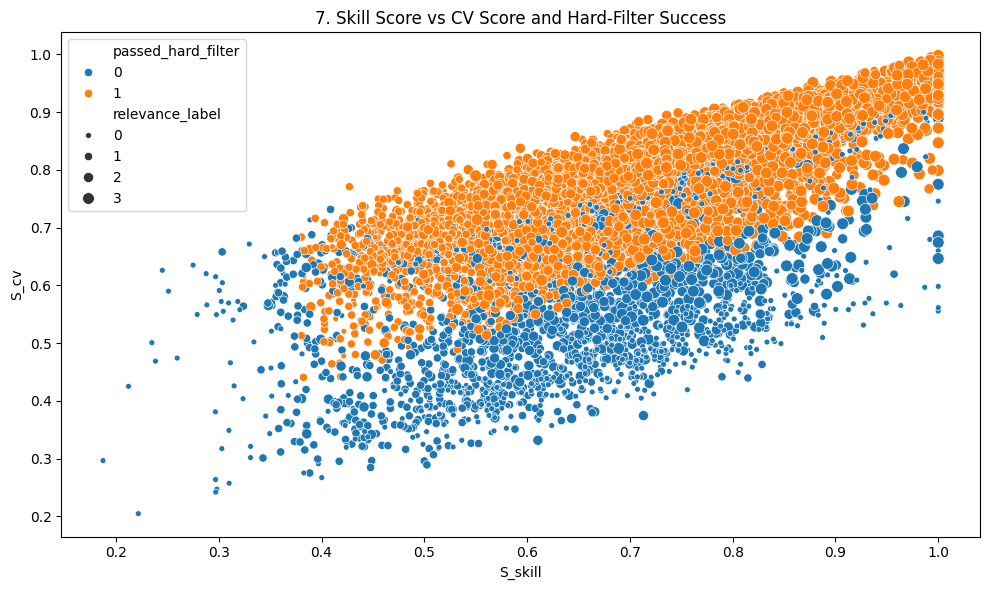

In [20]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='S_skill', y='S_cv', hue='passed_hard_filter', size='relevance_label')
plt.title(f'{plot_no}. Skill Score vs CV Score and Hard-Filter Success')
show_fig()
plot_no += 1

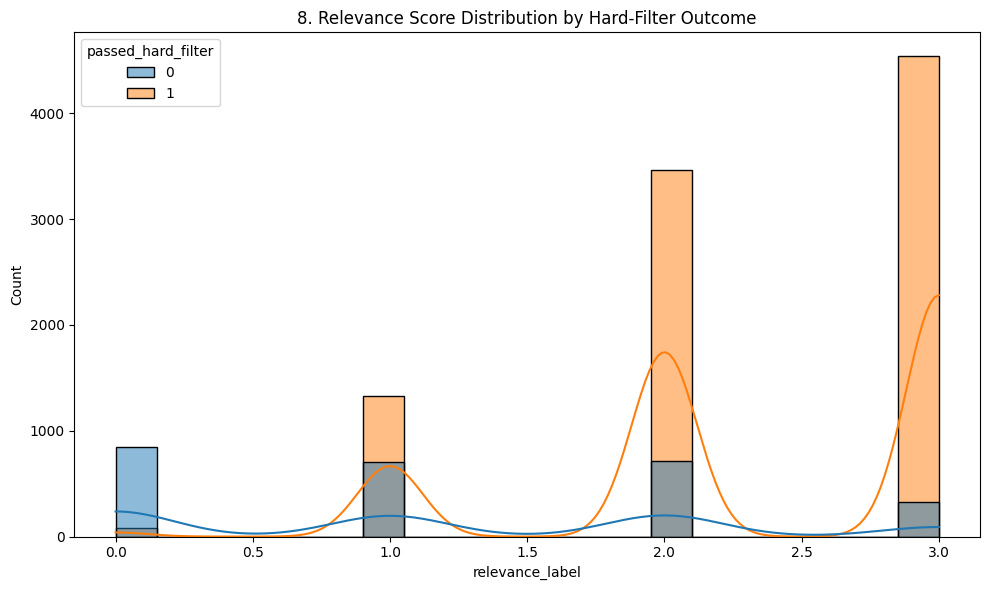

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='relevance_label', hue='passed_hard_filter', kde=True, bins=20)
plt.title(f'{plot_no}. Relevance Score Distribution by Hard-Filter Outcome')
show_fig()
plot_no += 1

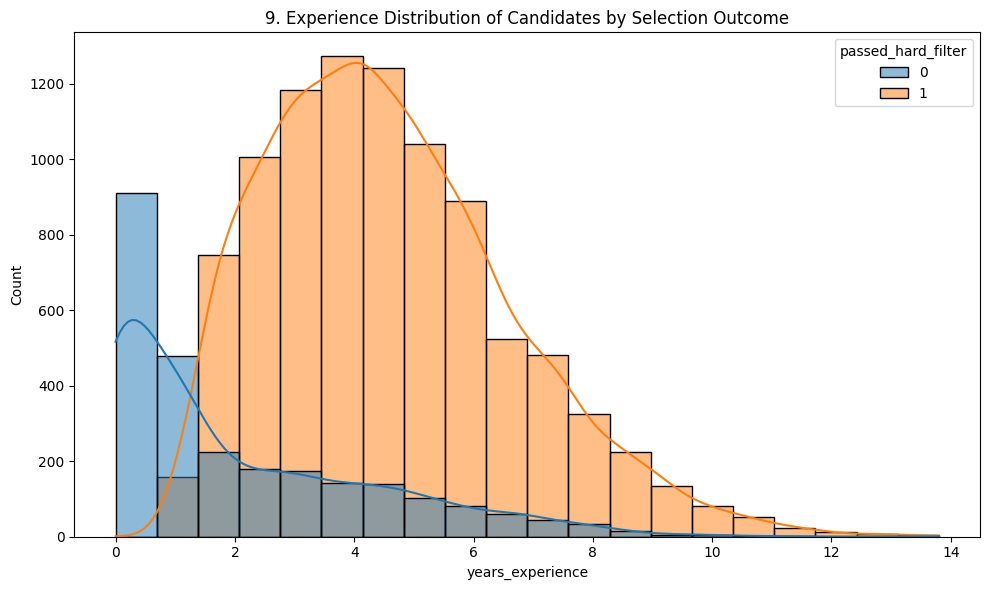

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='years_experience', hue='passed_hard_filter', kde=True, bins=20)
plt.title(f'{plot_no}. Experience Distribution of Candidates by Selection Outcome')
show_fig()
plot_no += 1

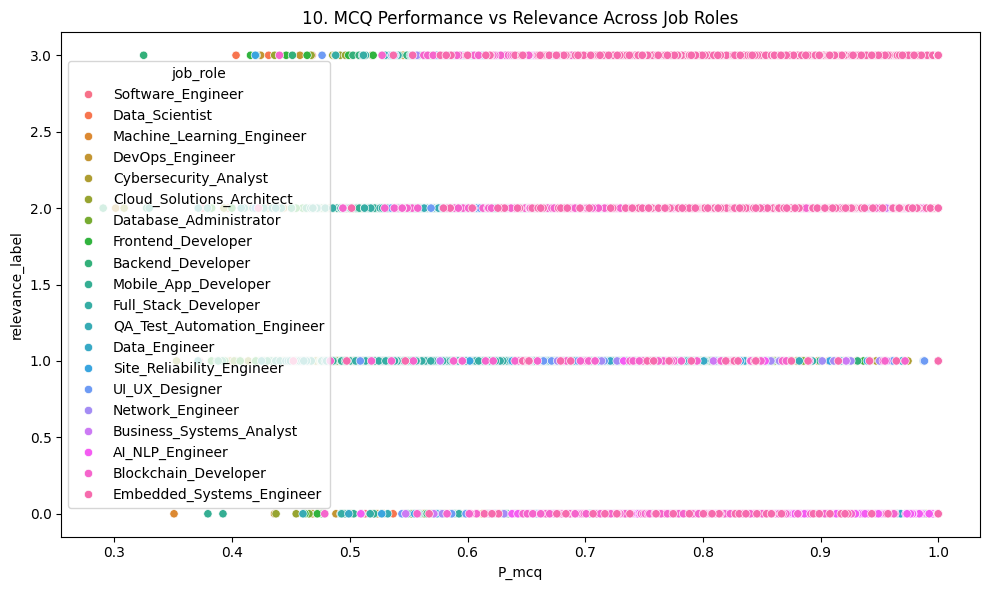

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='P_mcq', y='relevance_label', hue='job_role')
plt.title(f'{plot_no}. MCQ Performance vs Relevance Across Job Roles')
show_fig()
plot_no += 1

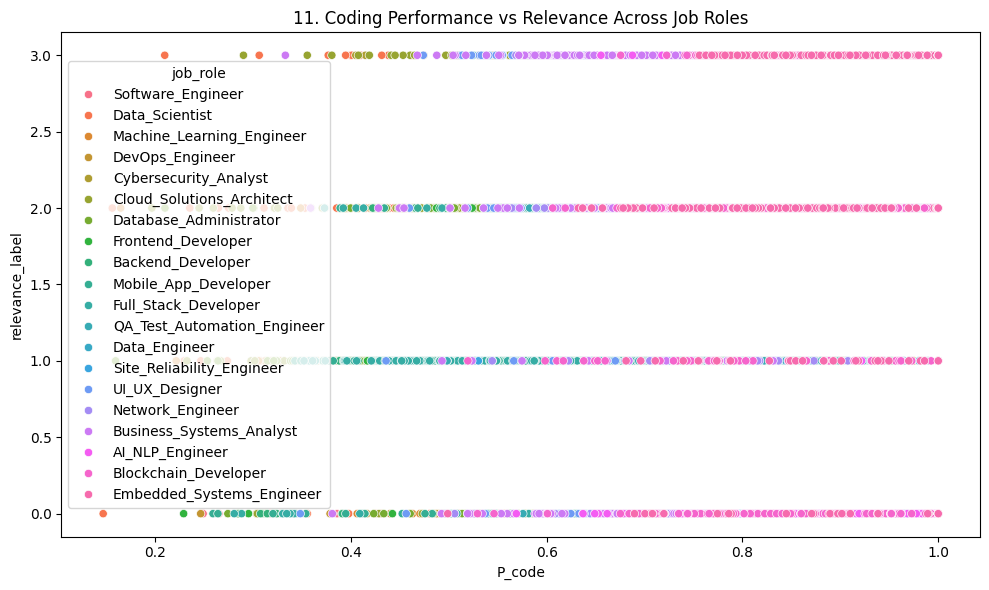

In [24]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='P_code', y='relevance_label', hue='job_role')
plt.title(f'{plot_no}. Coding Performance vs Relevance Across Job Roles')
show_fig()
plot_no += 1

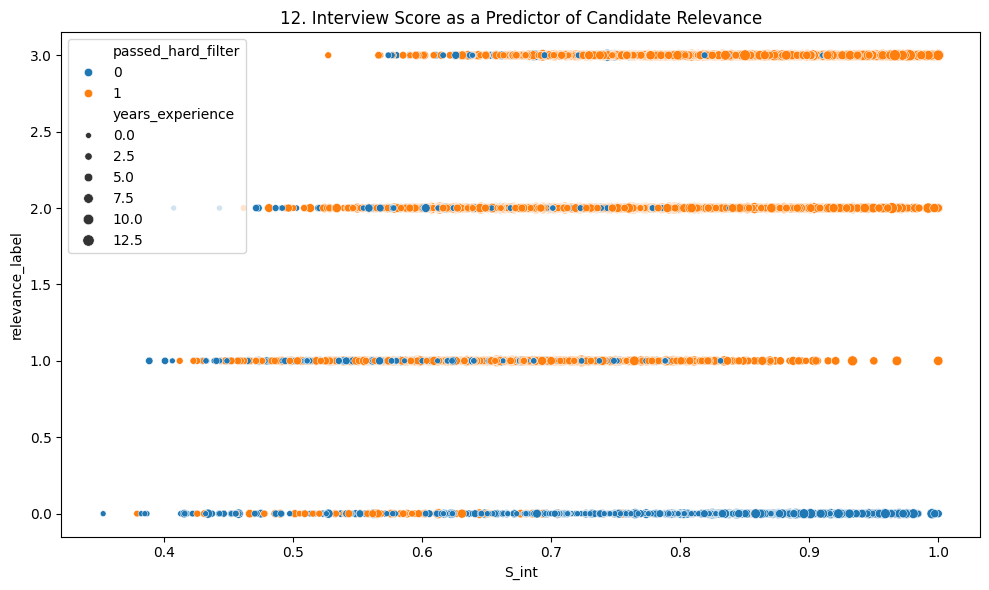

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='S_int', y='relevance_label', hue='passed_hard_filter', size='years_experience')
plt.title(f'{plot_no}. Interview Score as a Predictor of Candidate Relevance')
show_fig()
plot_no += 1

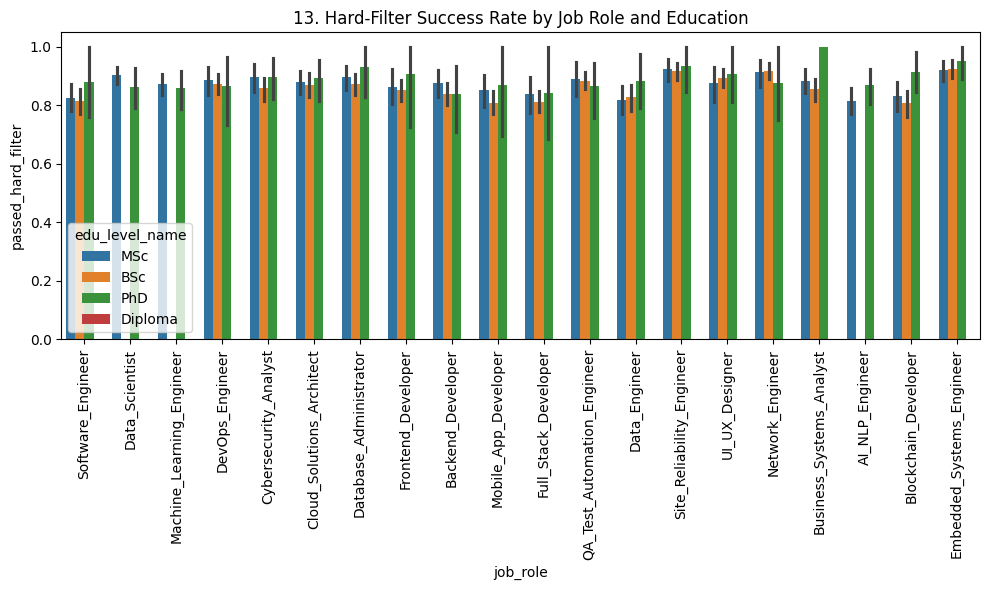

In [26]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='job_role', y='passed_hard_filter', hue='edu_level_name')
plt.title(f'{plot_no}. Hard-Filter Success Rate by Job Role and Education')
plt.xticks(rotation=90)
show_fig()
plot_no += 1

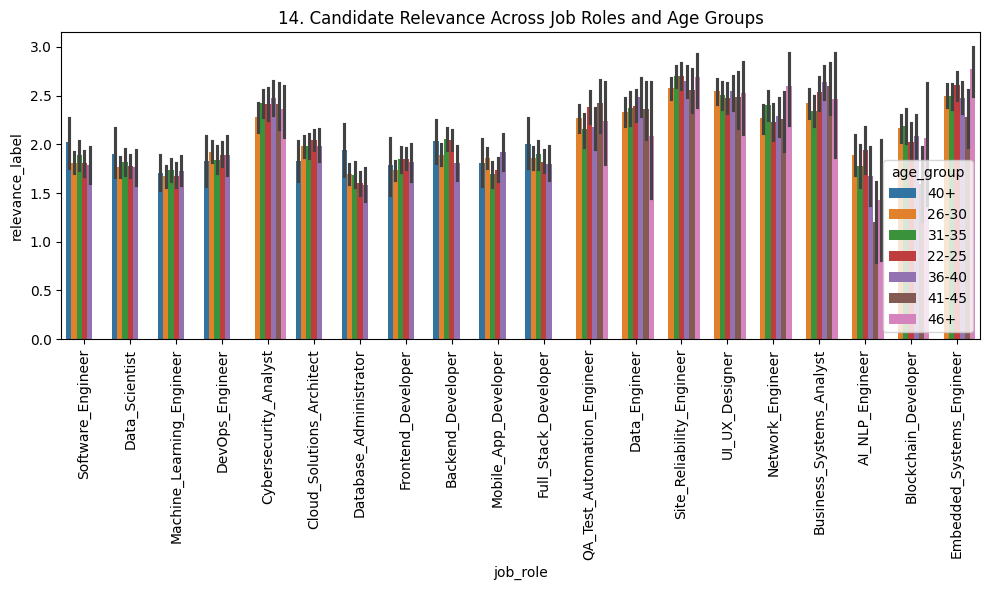

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(data=df, x='job_role', y='relevance_label', hue='age_group')
plt.title(f'{plot_no}. Candidate Relevance Across Job Roles and Age Groups')
plt.xticks(rotation=90)
show_fig()
plot_no += 1

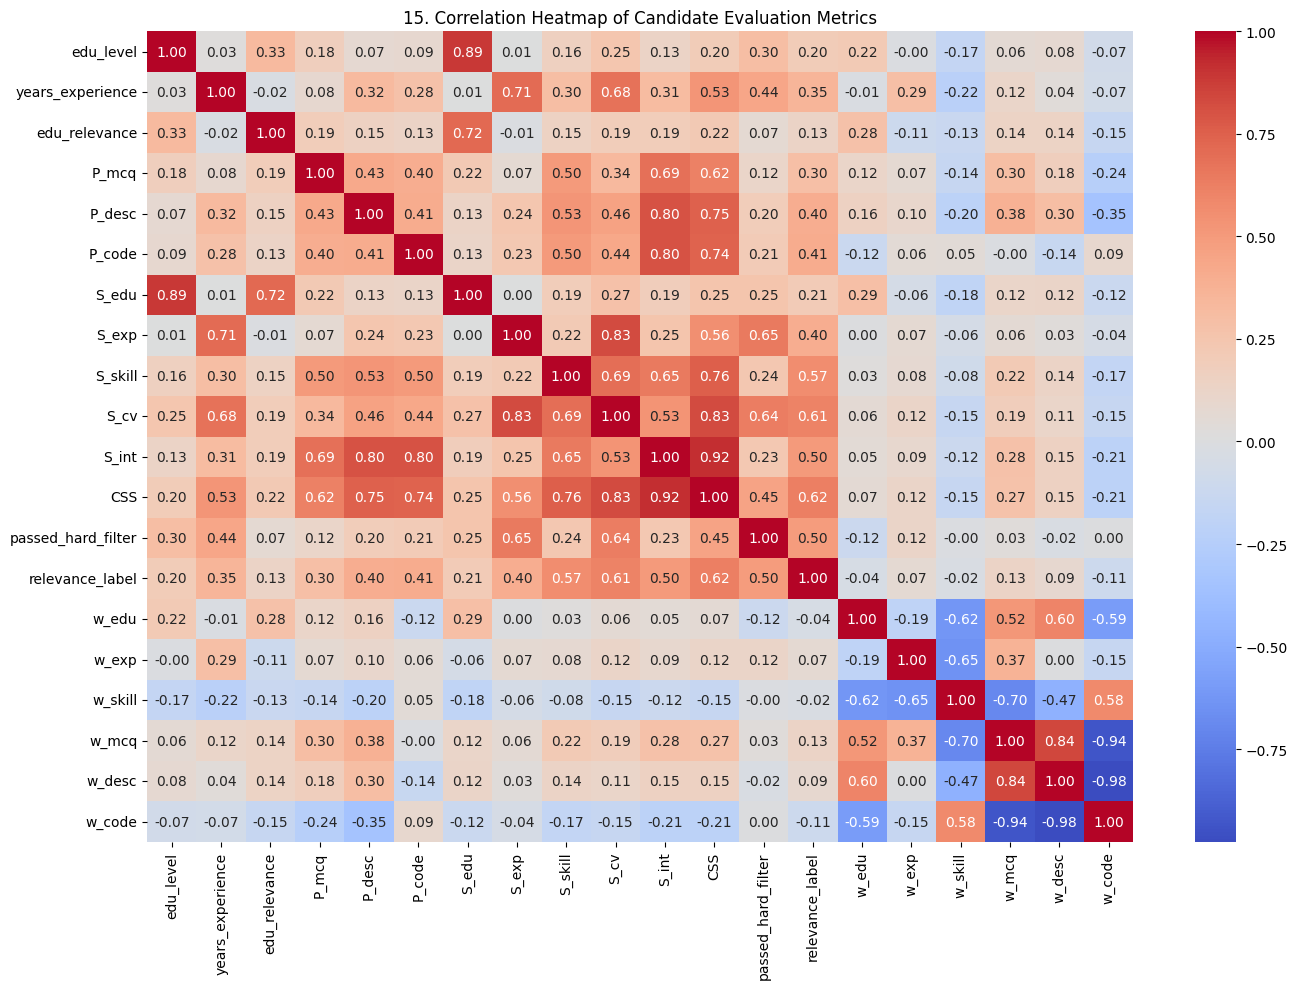

In [28]:
corr = df.select_dtypes(include='number').corr()

fig = plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap of Candidate Evaluation Metrics')
show_fig()
plot_no += 1

# Model Training

## Select useful features and target

In [29]:
X = df[['edu_level', 'years_experience', 'edu_relevance', 'P_mcq', 'P_desc', 'P_code',
        'S_edu', 'S_exp', 'S_skill', 'S_cv', 'S_int', 'CSS']]
y = df['passed_hard_filter']

## Split data into training and testing sets

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Build SVM model with feature scaling

In [31]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SVC(kernel='rbf', random_state=42))
])

## Train the model

In [32]:
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


## Make predictions

In [33]:
y_pred = model.predict(X_test)

## Calculate model accuracy

In [34]:
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9483333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.78      0.87       518
           1       0.94      1.00      0.97      1882

    accuracy                           0.95      2400
   macro avg       0.96      0.89      0.92      2400
weighted avg       0.95      0.95      0.95      2400



## Create confusion matrix

In [35]:
cm = confusion_matrix(y_test, y_pred)

## Plot actual versus predicted classification results

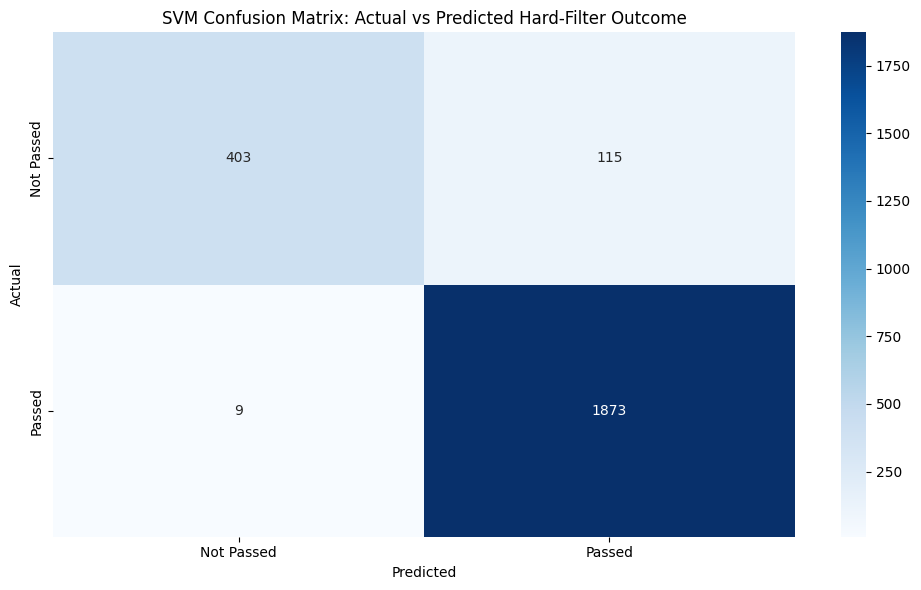

In [36]:
fig = plt.figure(figsize=(10, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Passed', 'Passed'],
            yticklabels=['Not Passed', 'Passed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix: Actual vs Predicted Hard-Filter Outcome')
plt.tight_layout()
plt.show()